In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
dir = './data'
train_sequences = pd.read_pickle(f"{dir}/train_sequences.pkl")
test_sequences = pd.read_pickle(f"{dir}/test_sequences.pkl")

In [3]:
train_sequences.shape, test_sequences.shape

((285980, 34), (291575, 34))

In [4]:
train_sequences.head(1)

,date,smart_9_raw,smart_197_raw,smart_241_raw,smart_242_raw,smart_7_raw,smart_193_raw,smart_1_raw,smart_240_raw,smart_198_raw,...,smart_196_raw,smart_183_raw,smart_199_raw,smart_200_raw,smart_225_raw,serial_number,model,capacity_bytes,failure,label
0,2016-10-13,0.722535,0.0,0.0,0.0,0.0,0.000369,0.0,0.0,0.0,...,0.714656,0.0,0.0,0.0,0.0,MJ0351YNG9ZJAA,Hitachi HDS5C3030ALA630,3.000593e+12,0.0,1


### Splitting and Reshaping Train/Test

In [3]:
X_train = train_sequences.drop(columns=['label', 'serial_number', 'date', 'model', 'capacity_bytes', 'failure'])
y_train = train_sequences['label']

In [4]:
X_train.shape, y_train.shape

((285980, 28), (285980,))

In [5]:
X_test = test_sequences.drop(columns=['label', 'serial_number', 'date', 'model', 'capacity_bytes', 'failure'])
y_test = test_sequences['label']

In [6]:
X_test.shape, y_test.shape

((291575, 28), (291575,))

In [7]:
X_train.columns

Index(['smart_9_raw', 'smart_197_raw', 'smart_241_raw', 'smart_242_raw',
       'smart_7_raw', 'smart_193_raw', 'smart_1_raw', 'smart_240_raw',
       'smart_198_raw', 'smart_194_raw', 'smart_4_raw', 'smart_12_raw',
       'smart_187_raw', 'smart_192_raw', 'smart_190_raw', 'smart_5_raw',
       'smart_3_raw', 'smart_195_raw', 'smart_189_raw', 'smart_191_raw',
       'smart_2_raw', 'smart_188_raw', 'smart_8_raw', 'smart_196_raw',
       'smart_183_raw', 'smart_199_raw', 'smart_200_raw', 'smart_225_raw'],
      dtype='str')

In [8]:
sequence_length = 5
num_features = X_train.shape[1]

In [9]:
def create_sequences(df, feature_cols, sequence_length):
    X = []
    y = []

    for drive in df['serial_number'].unique():
        df_drive = df[df['serial_number'] == drive].sort_values('date')

        data = df_drive[feature_cols].values
        labels = df_drive['label'].values

        for i in range(len(df_drive) - sequence_length):
            X.append(data[i:i+sequence_length])
            y.append(labels[i+sequence_length-1])

    return np.array(X), np.array(y)

In [10]:
feature_cols = X_train.columns.tolist()

X_train, y_train = create_sequences(train_sequences, feature_cols, 5)
X_test, y_test = create_sequences(test_sequences, feature_cols, 5)

In [11]:
X_train.shape, y_train.shape

((281875, 5, 28), (281875,))

In [12]:
X_test.shape, y_test.shape

((287225, 5, 28), (287225,))

In [13]:
print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([280618,   1257]))


### Modeling

In [24]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Attention, GlobalAveragePooling1D
from tensorflow.keras.models import Model

In [15]:
kernel_size = 2
filters = 64
lstm_units = 64
dropout_rate = 0.3
recurrent_dropout_rate = 0.2
l2_lambda = 0.001

In [25]:
inputs = Input(shape=(sequence_length, num_features))

x = LSTM(128, return_sequences=True)(inputs)
x = LSTM(64, return_sequences=True)(x)

attention = Attention()([x, x])

x = GlobalAveragePooling1D()(attention)

x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

In [26]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

In [27]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int64(0): np.float64(0.5022396995203444), np.int64(1): np.float64(112.12211614956244)}


In [28]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    class_weight = {0: 1, 1: 50}
)

Epoch 1/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 126s 28ms/step - accuracy: 0.9954 - auc_2: 0.5982 - loss: 0.5736 - val_accuracy: 0.9945 - val_auc_2: 0.7010 - val_loss: 0.1756
Epoch 2/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 210s 48ms/step - accuracy: 0.9934 - auc_2: 0.6517 - loss: 0.5536 - val_accuracy: 0.9946 - val_auc_2: 0.7121 - val_loss: 0.2036
Epoch 3/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 225s 51ms/step - accuracy: 0.9919 - auc_2: 0.6727 - loss: 0.5451 - val_accuracy: 0.9934 - val_auc_2: 0.7274 - val_loss: 0.1739
Epoch 4/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 242s 55ms/step - accuracy: 0.9902 - auc_2: 0.6780 - loss: 0.5420 - val_accuracy: 0.9867 - val_auc_2: 0.7245 - val_loss: 0.1874
Epoch 5/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 229s 52ms/step - accuracy: 0.9877 - auc_2: 0.6880 - loss: 0.5384 - val_accuracy: 0.9863 - val_auc_2: 0.7197 - val_loss: 0.2041
Epoch 6/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 245s 56ms/step - accuracy: 0.9867 - auc_2: 0.6931 - loss: 0.5338 - val_accuracy: 0.9900 - val_auc_2: 0.7226 - val

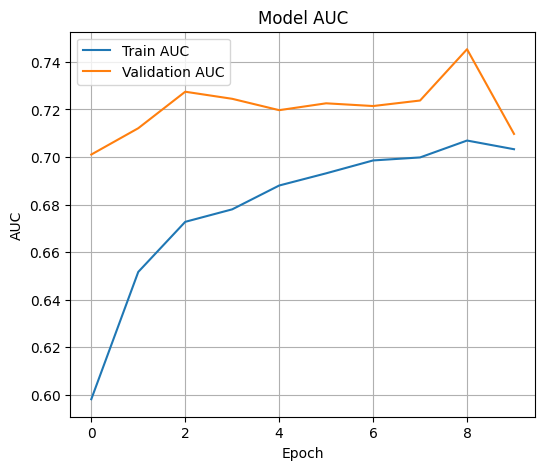

In [33]:
plt.figure(figsize=(6,5))

plt.plot(
    history.history['auc_2'],
    label='Train AUC'
)

plt.plot(
    history.history['val_auc_2'],
    label='Validation AUC'
)

plt.title('Model AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')

plt.legend()
plt.grid()

plt.show()

In [35]:
from sklearn.metrics import confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype(int)


8976/8976 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step


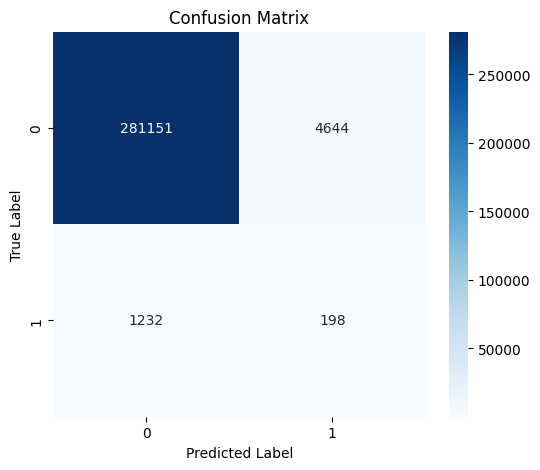

In [37]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    285795
           1       0.04      0.14      0.06      1430

    accuracy                           0.98    287225
   macro avg       0.52      0.56      0.53    287225
weighted avg       0.99      0.98      0.99    287225



8976/8976 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step


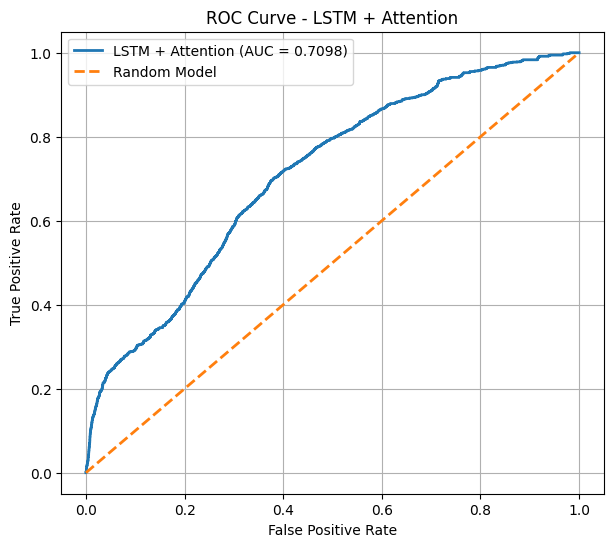

In [39]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_proba = model.predict(X_test).ravel()

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'LSTM + Attention (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2,
    label='Random Model'
)

plt.title('ROC Curve - LSTM + Attention')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.grid()

plt.show()